In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

/jet/home/hsun3/.local/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/jet/home/hsun3/.local/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# -----------------------------
# Read data
# -----------------------------
file = "./Raw_Data/clp/era5_clp_01.tab"

cols = [
    "lon","lat",
    "z_mean","p_mean","T_mean","H2O_mean","O3_mean",
    "z_std","p_std","T_std","H2O_std","O3_std",
    "npoints","freq"
]

data = pd.read_csv(
    file,
    comment="#",
    delim_whitespace=True,
    names=cols
)

/var/tmp/ipykernel_91020/2701050346.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(


In [4]:
data.head()

,lon,lat,z_mean,p_mean,T_mean,H2O_mean,O3_mean,z_std,p_std,T_std,H2O_std,O3_std,npoints,freq
0,-180.0,-90.0,8.57925,298.534,219.645,0.000051,1.065140e-07,0.561481,22.6283,2.58977,0.000014,3.031500e-08,14880,100.0
1,-179.7,-90.0,8.57925,298.534,219.645,0.000051,1.065140e-07,0.561482,22.6283,2.58977,0.000014,3.031500e-08,14880,100.0
2,-179.4,-90.0,8.57924,298.534,219.645,0.000051,1.065140e-07,0.561482,22.6283,2.58977,0.000014,3.031500e-08,14880,100.0
3,-179.1,-90.0,8.57925,298.534,219.645,0.000051,1.065140e-07,0.561483,22.6283,2.58977,0.000014,3.031500e-08,14880,100.0
4,-178.8,-90.0,8.57925,298.534,219.645,0.000051,1.065140e-07,0.561483,22.6283,2.58977,0.000014,3.031500e-08,14880,100.0


In [5]:
# -----------------------------
# Convert to 2D grid
# -----------------------------
lon = np.sort(data.lon.unique())
lat = np.sort(data.lat.unique())

Z = data.pivot(index="lat", columns="lon", values="z_mean").values

lon2d, lat2d = np.meshgrid(lon, lat)

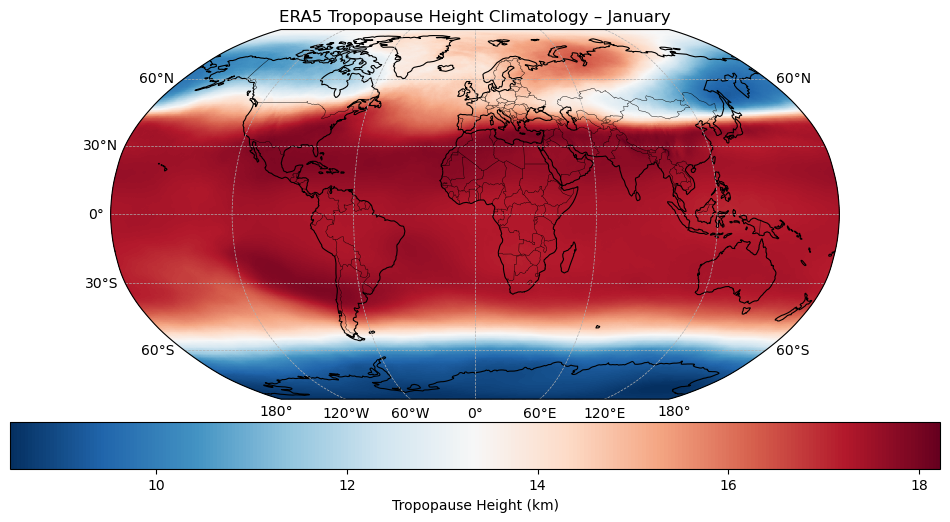

In [10]:

# -----------------------------
# Plot map
# -----------------------------
fig = plt.figure(figsize=(12,6))

ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()

mesh = ax.pcolormesh(
    lon2d,
    lat2d,
    Z,
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r"
)

# coastlines
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)

# -----------------------------
# Add latitude / longitude lines
# -----------------------------
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.5,
    linestyle="--"
)

gl.top_labels = False
gl.right_labels = False

# -----------------------------
# Colorbar
# -----------------------------
cbar = plt.colorbar(mesh, orientation="horizontal", pad=0.05)
cbar.set_label("Tropopause Height (km)")

plt.title("ERA5 Tropopause Height Climatology – January")

plt.show()